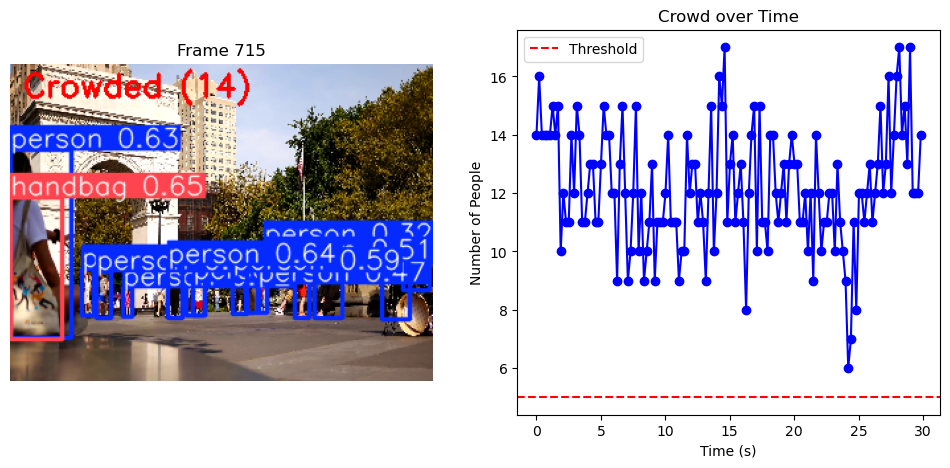

✅ Analysis saved to 'crowd_status_results.csv'


In [9]:
import cv2
import cv2
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output
from ultralytics import YOLO

# Parameters
MAX_DURATION_SEC = 30
FRAME_SKIP = 5
RESIZE_DIMS = (320, 240)
PERSON_THRESHOLD = 5

video_path = r"D:\Path to the video"
model = YOLO("yolov8n.pt")

# Initialize video
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(min(cap.get(cv2.CAP_PROP_FRAME_COUNT), MAX_DURATION_SEC * fps))

#  result storage
crowd_data = []
frame_id = 0
times = []
people_counts = []

# Plotting
plt.ion()
fig, (ax_video, ax_graph) = plt.subplots(1, 2, figsize=(12, 5))

while frame_id < total_frames:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_id % FRAME_SKIP == 0:
        resized = cv2.resize(frame, RESIZE_DIMS)
        results = model(resized, verbose=False)[0]
        num_people = sum(1 for c in results.boxes.cls if model.names[int(c)] == 'person')
        status = "Crowded" if num_people > PERSON_THRESHOLD else "Calm"

        # Save data
        crowd_data.append({
            "frame": frame_id,
            "time_sec": round(frame_id / fps, 2),
            "num_people": num_people,
            "status": status
        })

        # Annotate frame
        annotated = results.plot()
        cv2.putText(annotated, f"{status} ({num_people})", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.8,
                    (0, 0, 255) if status == "Crowded" else (0, 255, 0), 2)

        # Update plots
        ax_video.clear()
        ax_graph.clear()

        # Plot video frame
        ax_video.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax_video.set_title(f"Frame {frame_id}")
        ax_video.axis("off")

        # Plot graph
        times.append(frame_id / fps)
        people_counts.append(num_people)
        ax_graph.plot(times, people_counts, color="blue", marker="o")
        ax_graph.axhline(y=PERSON_THRESHOLD, color="red", linestyle="--", label="Threshold")
        ax_graph.set_title("Crowd over Time")
        ax_graph.set_xlabel("Time (s)")
        ax_graph.set_ylabel("Number of People")
        ax_graph.legend()

        # Refresh display
        clear_output(wait=True)
        display(fig)
        plt.pause(0.001)

    frame_id += 1

cap.release()
plt.ioff()
plt.close()

# Save results
df = pd.DataFrame(crowd_data)
df.to_csv("crowd_status_results.csv", index=False)
print("✅ Analysis saved to 'crowd_status_results.csv'")



     ---------------------------------------- 39.4/39.4 MB 7.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\fakih\\anaconda3\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



     --------------------------------------- 13.1/13.1 MB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for cvlib: filename=cvlib-0.2.7-py3-none-any.whl size=10046378 sha256=a7e5192050e3a9694646b24fd94ad02fefe629a8824300f76c0f01f855d0ac86
  Stored in directory: c:\users\fakih\appdata\local\pip\cache\wheels\2c\b4\91\c6ddd31550a14fec141d21053f4a6fe5729c41aaf991baf2bc
  Created wheel for imutils: filename=imutils-0.5.4-py3-none-any.whl size=25854 sha256=e0c82b75115c1fa079149f04c1f602b5c238d0889d90cf368dd4a35be5d944d0
  Stored in directory: c:\users\fakih\appdata\local\pip\cache\wheels\c2\02\32\f3617a9f68bcc67eda3ebeb4514eba18f62e81ff439428109d
  Created wheel for progressbar: filename=progressbar